# Convert outputs to yearly zarr files

In [1]:
import re
import os
import sys

import zarr
import yaml
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
sys.path.insert(0, os.path.realpath('../libs/'))
import verif_utils as vu

### Get the target data for coord reference

In [4]:
# fn_target = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/C404/C404_GP_2020.zarr'
# ds_target = xr.open_zarr(fn_target)

## Gather prognostic outputs

### Combine raw netCDF4 to zarr

In [5]:
# ind_start = 0
# ind_end = 100

# ds_mem = []

# for i_mem in range(10):
#     source_dir = f'/glade/derecho/scratch/ksha/DWC/RAW_OUTPUT/CONUS_GP_CESM_mem{i_mem:02d}/'
#     fn_all = vu.get_nc_files(source_dir)[0]
#     fn_all = sorted(fn_all, key=lambda x: int(re.search(r'_(\d+)\.nc$', x).group(1)))[:-1]
    
#     ds_collect = []
    
#     for fn in fn_all[ind_start:ind_end]:
#         ds = xr.open_dataset(fn)
#         ds = ds.drop_vars(['forecast_hour'])
#         ds_collect.append(ds)
    
#     ds_final = xr.concat(ds_collect, dim='time')
    
#     ds_final = ds_final.rename({'latitude': 'south_north', 'longitude': 'west_east', 'level': 'bottom_top'})
#     ds_final['west_east'] = np.arange(336).astype(np.float32)
#     ds_final['south_north'] = np.arange(336).astype(np.float32)
#     ds_final['bottom_top'] = np.arange(12).astype(np.float32)
#     ds_mem.append(ds_final)

# ds_final = xr.concat(ds_mem, dim='member')


In [6]:
# ds_final = ds_final.assign_coords(member=np.arange(10))

# # =================================================== #
# # combine with diag
# ds_final = ds_final.chunk({'member': 10, 'time': 12, 'bottom_top': 12, 'south_north': 336, 'west_east': 336})

# # =================================================== #
# # zarr encodings
# dict_encoding = {}
# varnames = list(ds_final.keys())
# varname_4D = ['WRF_U', 'WRF_V', 'WRF_T', 'WRF_Q_tot_05', 'WRF_P']

# chunk_size_3d = dict(chunks=(10, 12, 336, 336))
# chunk_size_4d = dict(chunks=(10, 12, 12, 336, 336))
# compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)

# for i_var, var in enumerate(varnames):
#     if var in varname_4D:
#         dict_encoding[var] = {'compressor': compress, **chunk_size_4d}
#     else:
#         dict_encoding[var] = {'compressor': compress, **chunk_size_3d}

# save_name = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/opt_init_ERA5/prog_outputs/CESM/CESM_LEN_{ind_start:04d}_{ind_end:04d}_2025-01-01T00Z.zarr'
# ds_final.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)

In [14]:
ds = xr.open_zarr(save_name)[['WRF_T2',]]

In [16]:
T2 = ds.mean(['south_north', 'west_east'])['WRF_T2'].values

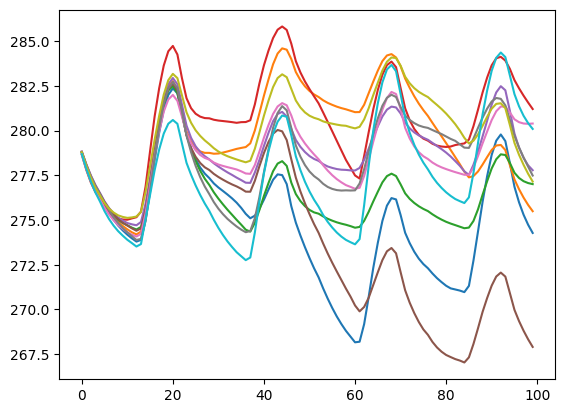

In [21]:
plt.plot(T2.T)

### Concat zarr to yearly

In [7]:
def extract_start_index(path):
    # Find numbers like _0000_1000_ and take the first one
    match = re.search(r'_(\d+)_\d+_', path)
    return int(match.group(1)) if match else float('inf')

def year_from_dt64(dt64):
    """Convert numpy.datetime64[ns] to integer year."""
    return dt64.astype("datetime64[Y]").astype(int) + 1970

def first_day_of_year(dt64):
    """Return the datetime64[ns] of the first day of the year for dt64."""
    return dt64.astype("datetime64[Y]").astype("datetime64[ns]")

### CESM

In [8]:
for year in range(2027, 2028):
    base_dir = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/opt_init_ERA5/prog_outputs/CESM/'
    fn_all = sorted(glob(base_dir + '*.zarr'), key=extract_start_index)
    
    ds_collect = []
    flag_add_previous = True
    
    for i_fn, fn in enumerate(fn_all):
        ds = xr.open_zarr(fn)
    
        # Extract first timestamp
        first_day = ds['time'].values[0]
        year_ = year_from_dt64(first_day)
    
        if year_ != year:
            continue  # Skip years not matching target
        
        # If file starts mid-year, add the previous file once
        if (first_day != first_day_of_year(first_day)) and (i_fn > 0) and flag_add_previous and (year != 2025):
            print(fn)
            ds_prev = xr.open_zarr(fn_all[i_fn - 1])
            ds_collect.append(ds_prev)
            flag_add_previous = False
    
        ds_collect.append(ds)
    
    # Combine and trim to exact calendar year
    if not ds_collect:
        raise ValueError(f"No data found for year {year}")
    
    ds_final = xr.concat(ds_collect, dim='time')
    
    ds_final = ds_final.sel(time=slice(f"{year}-01-01T00:00:00", f"{year}-12-31T23:00:00"))
    ds_final = ds_final.chunk({'member': 10, 'time': 12, 'bottom_top': 12, 'south_north': 336, 'west_east': 336})
    
    # =================================================== #
    # zarr encodings
    dict_encoding = {}
    varnames = list(ds_final.keys())
    varname_4D = ['WRF_U', 'WRF_V', 'WRF_T', 'WRF_Q_tot_05', 'WRF_P']
    
    chunk_size_3d = dict(chunks=(10, 12, 336, 336))
    chunk_size_4d = dict(chunks=(10, 12, 12, 336, 336))
    compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)
    
    for i_var, var in enumerate(varnames):
        if var in varname_4D:
            dict_encoding[var] = {'compressor': compress, **chunk_size_4d}
        else:
            dict_encoding[var] = {'compressor': compress, **chunk_size_3d}
    
    base_dir = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/opt_init_ERA5/prog_outputs/'
    save_name = base_dir + f'opt_CESM_{year}.zarr'
    ds_final.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)
    print(save_name)

/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/opt_init_ERA5/prog_outputs/CESM/CESM_LEN_17640_17820_2025-01-01T00Z.zarr
/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_GP/opt_init_ERA5/prog_outputs/opt_CESM_2027.zarr
